# 방법 비교 — LASSO · Elastic-Net · Random LASSO · Hi-LASSO

네 방법의 특징 선택 성능(F1·AUCPR)을 Stochastic LASSO Fig 1 형식(2패널 박스플롯)으로 비교한다.
- LASSO·ENet: R glmnet 로컬 계산. Random·Hi: I·II 로컬 계산 / III·IV는 클러스터 저장물 로드(있을 때).
- 결과 그림은 `results/compare_fig.png`로도 저장.

**주의**: 방법·데이터셋마다 실행 기계(로컬 R vs 클러스터 sklearn)가 달라 재생성 데이터 미세차가 있음(정성 순위는 견고).

## 1. 준비

In [1]:
import os, sys, warnings
os.environ.setdefault("R_HOME", os.path.join(sys.prefix, "lib", "R"))
sys.path.insert(0, os.path.abspath(os.path.join("..", "lib")))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import generate_data as gd, scoring
ROOT = os.path.abspath(".."); RESDIR = os.path.join(ROOT, "results")
DSN = ["Dataset I", "Dataset II", "Dataset III", "Dataset IV"]
rows = []
def addrow(method, ds, rep, f1, auc):
    rows.append(dict(method=method, dataset=ds, rep=rep, f1=float(f1), aucpr=float(auc)))
print("준비 완료")

준비 완료


## 2. LASSO · Elastic-Net (R glmnet, 로컬 계산)

In [2]:
import solver
for method, ratios in [("LASSO",[1.0]),
                       ("Elastic-Net",[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])]:
    for ds in DSN:
        cfg = gd.DATASETS[ds]; beta = gd.build_beta(cfg)
        for rep in range(10):
            (Xtr,ytr),(Xval,yval),_ = gd.generate_split(cfg, beta, rep)
            best,_ = solver.select_model((Xtr,ytr),(Xval,yval), ratios)
            bh = best["bhat"]
            addrow(method, ds, rep, scoring.f1_selection(bh,beta)["f1"], scoring.aucpr(bh,beta))
    print(method, "done")

LASSO done


Elastic-Net done


## 3. Random LASSO (I·II 계산 / III·IV는 NPZ 로드)

In [3]:
import random_lasso as rl
npz_path = os.path.join(ROOT, "results_random_lasso.npz")
npz = np.load(npz_path) if os.path.exists(npz_path) else None
for ds in DSN:
    cfg = gd.DATASETS[ds]; beta = gd.build_beta(cfg)
    if ds in ("Dataset I","Dataset II"):
        for rep in range(10):
            (Xtr,ytr),(Xval,yval),_ = gd.generate_split(cfg, beta, rep)
            r = rl.fit_random_lasso(Xtr, ytr, Xval, yval, L=30, random_state=rep, n_jobs=-1)
            addrow("Random", ds, rep, scoring.f1_selection(r["coef_"],beta)["f1"], scoring.aucpr(r["beta_hat_"],beta))
    elif npz is not None and f"{ds}__beta_hats" in npz:
        for rep, bh in enumerate(npz[f"{ds}__beta_hats"]):
            (Xtr,ytr),(Xval,yval),_ = gd.generate_split(cfg, beta, rep)
            t,_,_ = rl._select_threshold(bh, Xval, yval, n_se=1.0)
            coef = np.where(np.abs(bh)>=t, bh, 0.0)
            addrow("Random", ds, rep, scoring.f1_selection(coef,beta)["f1"], scoring.aucpr(bh,beta))
    else:
        print(f"  Random {ds}: NPZ 없음 → 건너뜀(클러스터 결과 rsync 필요)")
    print("Random", ds, "done")

Random Dataset I done


Random Dataset II done


Random Dataset III done


Random Dataset IV done


## 4. Hi-LASSO (I·II 계산 / III·IV는 클러스터 CSV 로드)

In [4]:
hcsv = os.path.join(ROOT, "results_hi_lasso.csv")
hi_df = pd.read_csv(hcsv)          # 클러스터 수정본 결과(4개 데이터셋 per-rep)
for ds in DSN:
    sub = hi_df[hi_df.dataset == ds]
    for _, r in sub.iterrows():
        addrow("Hi-LASSO", ds, int(r["rep"]), r["f1"], r["aucpr"])
    print("Hi-LASSO", ds, "done (CSV 로드)")

Hi-LASSO Dataset I done (CSV 로드)
Hi-LASSO Dataset II done (CSV 로드)
Hi-LASSO Dataset III done (CSV 로드)
Hi-LASSO Dataset IV done (CSV 로드)


## 5. Fig 1 형식 박스플롯 (A: F1, B: AUCPR)

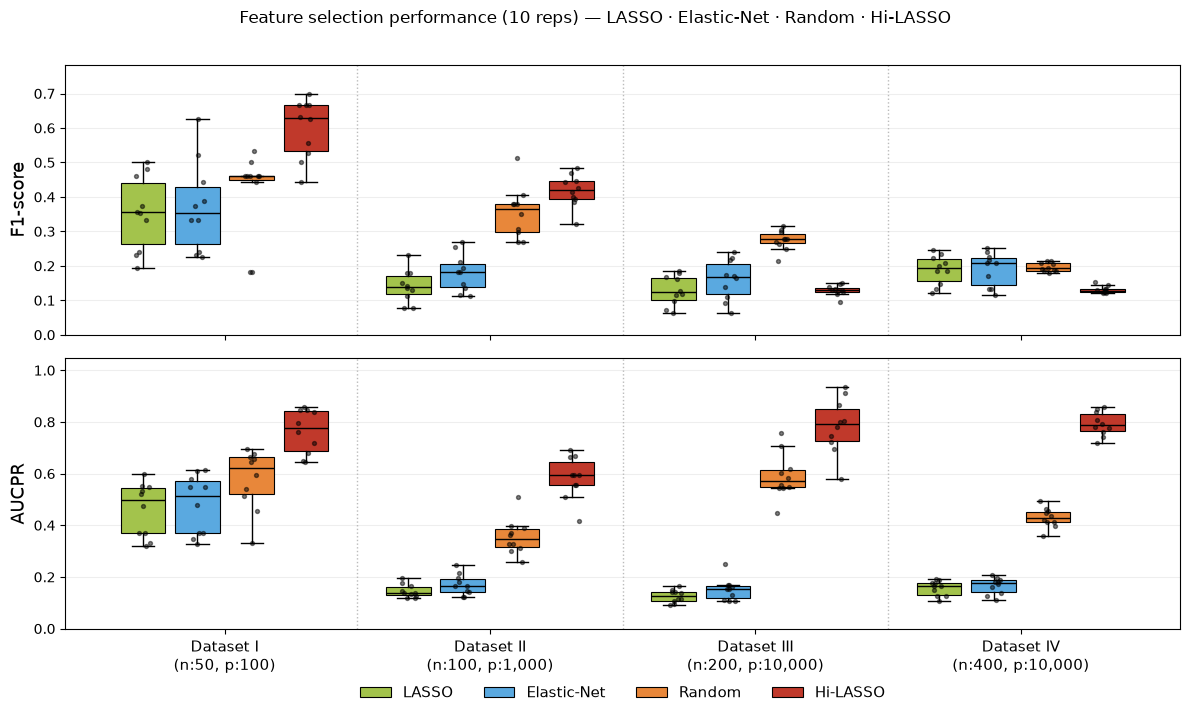

포함된 방법: ['LASSO', 'Elastic-Net', 'Random', 'Hi-LASSO'] | 저장: results/compare_fig.png


In [5]:
df = pd.DataFrame(rows)
METHODS = [m for m in ["LASSO","Elastic-Net","Random","Hi-LASSO"] if m in df.method.unique()]
COL = {"LASSO":"#a3c34c","Elastic-Net":"#5aa9e0","Random":"#e8873a","Hi-LASSO":"#c0392b"}
LAB = {"Dataset I":"Dataset I\n(n:50, p:100)","Dataset II":"Dataset II\n(n:100, p:1,000)",
       "Dataset III":"Dataset III\n(n:200, p:10,000)","Dataset IV":"Dataset IV\n(n:400, p:10,000)"}
gw = 0.82
fig, axes = plt.subplots(2, 1, figsize=(12, 7.4), sharex=True)
for ax, metric, title in [(axes[0],"f1","F1-score"),(axes[1],"aucpr","AUCPR")]:
    for gi, ds in enumerate(DSN):
        for mi, m in enumerate(METHODS):
            vals = df[(df.method==m)&(df.dataset==ds)][metric].values
            if len(vals)==0: continue
            pos = gi + (mi-(len(METHODS)-1)/2)*(gw/len(METHODS))
            bp = ax.boxplot([vals], positions=[pos], widths=gw/len(METHODS)*0.82,
                            patch_artist=True, medianprops=dict(color="black",lw=1),
                            flierprops=dict(marker=""))
            bp["boxes"][0].set(facecolor=COL[m], edgecolor="black", lw=0.8)
            ax.scatter(np.full(len(vals),pos)+np.random.uniform(-0.03,0.03,len(vals)),
                       vals, s=8, color="black", alpha=0.5, zorder=3)
        if gi < len(DSN)-1: ax.axvline(gi+0.5, color="#bbb", ls=":", lw=1)
    ax.set_ylabel(title, fontsize=13); ax.grid(axis="y", color="#eee", lw=0.8)
    ax.set_ylim(0, max(0.05, df[metric].max()*1.12)); ax.set_xlim(-0.6, len(DSN)-0.4)
axes[1].set_xticks(range(len(DSN))); axes[1].set_xticklabels([LAB[d] for d in DSN], fontsize=11)
handles=[plt.Rectangle((0,0),1,1,facecolor=COL[m],edgecolor="black",lw=0.8) for m in METHODS]
axes[1].legend(handles, METHODS, ncol=len(METHODS), loc="upper center",
               bbox_to_anchor=(0.5,-0.16), frameon=False, fontsize=11)
fig.suptitle("Feature selection performance (10 reps) — "+" · ".join(METHODS), fontsize=12.5, y=0.98)
plt.tight_layout(rect=(0,0.02,1,0.97))
os.makedirs(RESDIR, exist_ok=True)
plt.savefig(os.path.join(RESDIR,"compare_fig.png"), dpi=150, bbox_inches="tight")
plt.show()
print("포함된 방법:", METHODS, "| 저장: results/compare_fig.png")

## 6. 요약표 (평균 ± 표준오차)

In [6]:
pv = df.groupby(["dataset","method"])[["f1","aucpr"]].agg(["mean","sem"]).round(3)
pv

f1         aucpr       
                          mean    sem   mean    sem
dataset     method                                 
Dataset I   Elastic-Net  0.372  0.041  0.480  0.036
            Hi-LASSO     0.598  0.027  0.763  0.027
            LASSO        0.353  0.034  0.462  0.033
            Random       0.415  0.040  0.578  0.037
Dataset II  Elastic-Net  0.180  0.017  0.170  0.013
            Hi-LASSO     0.418  0.015  0.585  0.026
            LASSO        0.142  0.015  0.145  0.008
            Random       0.355  0.023  0.356  0.022
Dataset III Elastic-Net  0.159  0.019  0.151  0.013
            Hi-LASSO     0.130  0.005  0.784  0.034
            LASSO        0.129  0.014  0.126  0.008
            Random       0.275  0.009  0.591  0.028
Dataset IV  Elastic-Net  0.191  0.015  0.166  0.010
            Hi-LASSO     0.131  0.003  0.792  0.015
            LASSO        0.188  0.014  0.157  0.009
            Random       0.197  0.004  0.430  0.012